In [1]:
import sys
print(sys.executable)

d:\infotact\EconoCausal-Dynamic-Pricing\.venv\Scripts\python.exe


In [1]:
from econml.dml import LinearDML

In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

from econml.dml import LinearDML

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
model_df = pd.read_csv("../data/processed/causal_modeling_data.csv")

print(model_df.shape)
model_df.head()

(42268, 6)


,Treatment,Outcome,Year,Month,PreviousQuantity,TimeIndex
0,0.850000,255,2010,2,289.0,2
1,0.817500,633,2010,3,255.0,3
2,0.819048,1129,2010,4,633.0,4
3,0.832069,1409,2010,5,1129.0,5
4,0.845517,442,2010,6,1409.0,6


In [7]:
# Define treatment, outcome and covariates

T = model_df["Treatment"]

Y = model_df["Outcome"]

X = model_df[
    [
        "Year",
        "Month",
        "PreviousQuantity",
        "TimeIndex"
    ]
]

print("Treatment:", T.name)
print("Outcome:", Y.name)
print("Covariates:", X.columns.tolist())

Treatment: Treatment
Outcome: Outcome
Covariates: ['Year', 'Month', 'PreviousQuantity', 'TimeIndex']


In [4]:
print(model_df.columns.tolist())

['Treatment', 'Outcome', 'Year', 'Month', 'PreviousQuantity', 'TimeIndex']


In [6]:
model_df.head()

,Treatment,Outcome,Year,Month,PreviousQuantity,TimeIndex
0,0.850000,255,2010,2,289.0,2
1,0.817500,633,2010,3,255.0,3
2,0.819048,1129,2010,4,633.0,4
3,0.832069,1409,2010,5,1129.0,5
4,0.845517,442,2010,6,1409.0,6


In [8]:
print("Treatment shape:", T.shape)
print("Outcome shape:", Y.shape)
print("Covariates shape:", X.shape)

print("\nMissing values:")
print(X.isnull().sum())

Treatment shape: (42268,)
Outcome shape: (42268,)
Covariates shape: (42268, 4)

Missing values:
Year                0
Month               0
PreviousQuantity    0
TimeIndex           0
dtype: int64


In [9]:
model_y = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model_t = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [10]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [11]:
dml = LinearDML(
    model_y=model_y,
    model_t=model_t,
    cv=cv,
    random_state=42
)

print(dml)

In [12]:
RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"ma

In [13]:
print("Training Double Machine Learning model...")

dml.fit(
    Y=Y,
    T=T,
    X=X
)

print("Model trained successfully!")

Training Double Machine Learning model...
Model trained successfully!


d:\infotact\EconoCausal-Dynamic-Pricing\.venv\Lib\site-packages\econml\sklearn_extensions\linear_model.py:1946: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


In [14]:
ate = dml.ate(X=X)

print(f"Average Treatment Effect (ATE): {ate:.6f}")

Average Treatment Effect (ATE): -0.925718


In [15]:
lower, upper = dml.ate_interval(X=X)

print("95% Confidence Interval")
print(f"Lower Bound : {lower:.6f}")
print(f"Upper Bound : {upper:.6f}")

95% Confidence Interval
Lower Bound : -1.807528
Upper Bound : -0.043908


In [16]:
treatment_effects = dml.effect(X)

print("First 10 Individual Treatment Effects:")

print(treatment_effects[:10])

First 10 Individual Treatment Effects:
[-1.82229034 -1.67387931 -2.08735098 -2.66175021 -2.94157017 -1.5207403
 -1.5018896  -1.50622338 -0.90503308 -1.91857365]


In [17]:
print(pd.Series(treatment_effects).describe())

count    42268.000000
mean        -0.925718
std          0.757916
min        -27.576399
25%         -1.191581
50%         -0.839047
75%         -0.514109
max          0.118881
dtype: float64


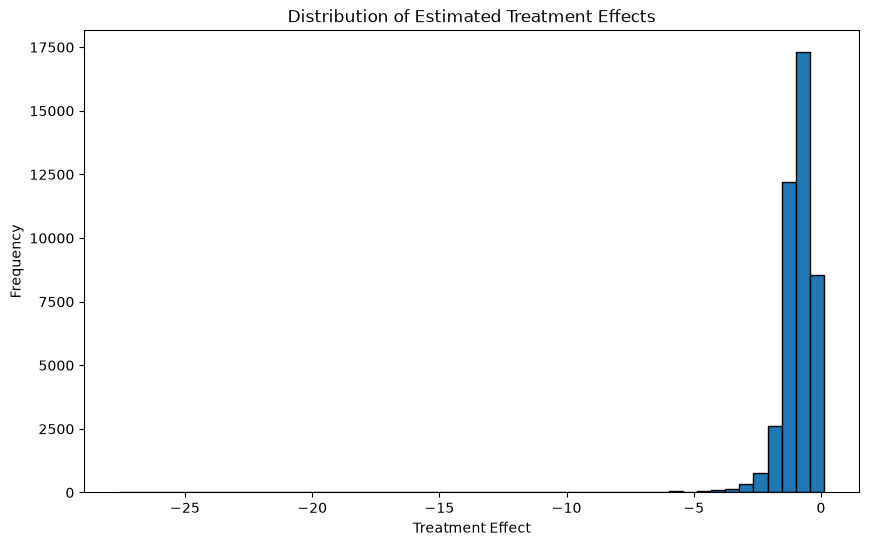

In [18]:
plt.figure(figsize=(10,6))

plt.hist(
    treatment_effects,
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Estimated Treatment Effects")
plt.xlabel("Treatment Effect")
plt.ylabel("Frequency")

plt.show()

In [19]:
from econml.dml import LinearDML

In [20]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(dml.const_marginal_effect(X)).mean(axis=0)
})

feature_importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

feature_importance

,Feature,Importance
0,Year,0.928579
1,Month,0.928579
2,PreviousQuantity,0.928579
3,TimeIndex,0.928579


In [21]:
# Create the Double Machine Learning model

dml_model = LinearDML(
    model_y=RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    model_t=RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    cv=KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),

    random_state=42
)

print("LinearDML model created successfully!")

LinearDML model created successfully!


In [22]:
print("Training Double Machine Learning model...")

dml_model.fit(
    Y=Y,
    T=T,
    X=X
)

print("Training completed!")

Training Double Machine Learning model...
Training completed!


d:\infotact\EconoCausal-Dynamic-Pricing\.venv\Lib\site-packages\econml\sklearn_extensions\linear_model.py:1946: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


In [23]:
from econml.dml import LinearDML

In [24]:
# Estimate Conditional Average Treatment Effect (CATE)

treatment_effect = dml_model.effect(X)

print("Treatment effects estimated!")
print("Number of estimates:", len(treatment_effect))

Treatment effects estimated!
Number of estimates: 42268


In [25]:
effect_df = pd.DataFrame({
    "EstimatedTreatmentEffect": treatment_effect
})

effect_df.head()

,EstimatedTreatmentEffect
0,-1.822290
1,-1.673879
2,-2.087351
3,-2.661750
4,-2.941570


In [26]:
effect_df.describe()

,EstimatedTreatmentEffect
count,42268.000000
mean,-0.925718
std,0.757916
min,-27.576399
25%,-1.191581
50%,-0.839047
75%,-0.514109
max,0.118881


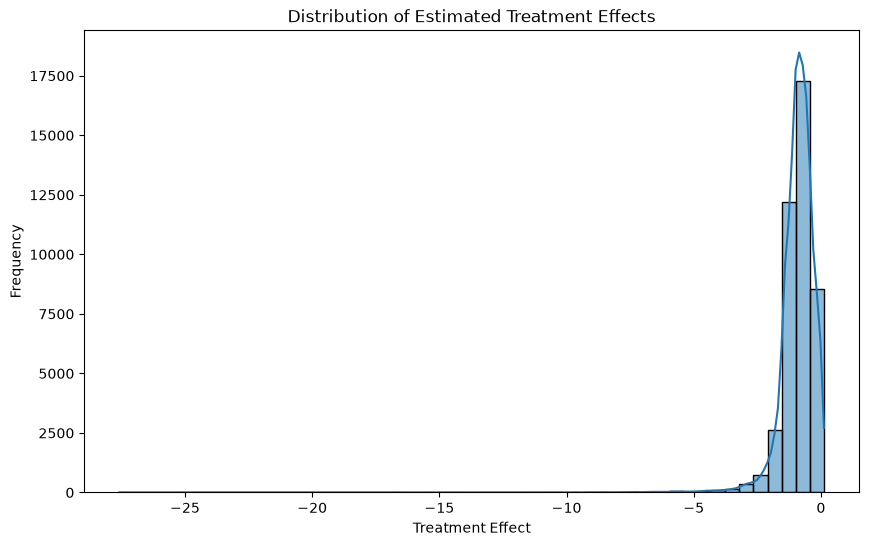

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    treatment_effect,
    bins=50,
    kde=True
)

plt.title("Distribution of Estimated Treatment Effects")
plt.xlabel("Treatment Effect")
plt.ylabel("Frequency")

plt.show()

In [28]:
# Average Treatment Effect

ate = np.mean(treatment_effect)

print(f"Average Treatment Effect (ATE): {ate:.4f}")

Average Treatment Effect (ATE): -0.9257


In [29]:
# Confidence interval for the ATE

lb, ub = dml_model.ate_interval(X)

print("95% Confidence Interval")
print("Lower Bound:", lb)
print("Upper Bound:", ub)

95% Confidence Interval
Lower Bound: -1.8075283108091214
Upper Bound: -0.043907816379880615


In [30]:
# Attach treatment effects to the original data

results_df = model_df.copy()

results_df["EstimatedTreatmentEffect"] = treatment_effect

results_df.head()

,Treatment,Outcome,Year,Month,PreviousQuantity,TimeIndex,EstimatedTreatmentEffect
0,0.850000,255,2010,2,289.0,2,-1.822290
1,0.817500,633,2010,3,255.0,3,-1.673879
2,0.819048,1129,2010,4,633.0,4,-2.087351
3,0.832069,1409,2010,5,1129.0,5,-2.661750
4,0.845517,442,2010,6,1409.0,6,-2.941570


In [ ]:
# Conclusion

- LinearDML was successfully trained.
- Individual Treatment Effects (ITE) were estimated.
- Average Treatment Effect (ATE) was calculated.
- A 95% confidence interval for the ATE was obtained.
- Product-level analysis was skipped because the modeling dataset does not contain a StockCode column.